We saw that the column-based approach was faster than the row-based approach.
We'll now expand on the column-based approach by moving from the recursive query
to a setup where we write each recursion step manually to an intermediary table.
This means that we're no longer working fully in SQL, but we do get cleaner and
faster queries, as we'll see.

We will work once more with our familiar LRA formula in $k$ dimensions:

 $\exists x_1,\ldots ,x_k\ .\ (F(x_1, \ldots, x_k) > k) \land (x_1 < k) \land
 ... \land (x_k < k)$

## Database schema

 


We have the same `LinearConstraint` table as before. However, we will now also
create tables for each projection step. Say we start with 4 dimensions. We then
have:

- `LinearConstraint(id, description, constraint_dimension, a0, ..., a4)`: our
  constraints in the highest dimensions. Note we add `constraint_dimension`, the
  highest nonzero dimension of the constraint. This is purely practical; we
  could deduce the same in SQL.
- `Projection_Dimension3(id, constraint_dimension, a0, ..., a3)`: the result of
  projecting away dimension 4
- `Projection_Dimension2(id, constraint_dimensions, a0, a1, a2)`: the result of
  projecting away dimension3.

We don't need `Projection_Dimension1`, since we do the step going from 2
dimensions to x-values in a single query.

For the lifting phase, we create a series of tables that represent our final
CAD:

- `Lift_Dimension1(id, x1)`: the sample points of our 1D CAD (so, univariate
  values).
- `Lift_Dimension2(id, base_cell, x2)`: the y-values of our CAD. We can join on
  the `base_cell` to get our full sample points.
- `Lift_Dimension3` and `Lift_Dimension4` are similar.

For now we also have a `Result` table to hold the truth value of each
$n$-dimensional cell, though that won't be used anymore in later notebooks.

## The Code

We immediately write some code for the general $n$-dimensional case. A few
things to note:

- Almost all queries are now templates with some placeholders. Actual queries
  get written to a `build` directory so we can see what actually gets run.
- There's a lot of code here. In later notebooks we move this to some library
  code, and slightly tidied up.

In [9]:
from pathlib import Path
import duckdb as db

DBNAME = "dbs/cad_columns_intermediate.db"
DEBUG=True
queries_dir = Path("queries/column-based-intermediate")

with open(queries_dir / 'project.sql', 'r', encoding='utf-8') as file:
    project_template = file.read()

with open(queries_dir / 'x_values.sql', 'r', encoding='utf-8') as file:
    x_values_query = file.read()

with open(queries_dir / 'lift.sql', 'r', encoding='utf-8') as file:
    lift_template = file.read()

with open(queries_dir / "results.sql", 'r', encoding='utf-8') as file:
    results_template = file.read()

def write_query(filename, query):
    if DEBUG:
        with open(Path('build') / filename, 'w', encoding='utf-8') as f:
            f.write(query)


def project_n(n, max_dim):
    intersect_calculation_coeffs = ""
    for i in range(0, n):
        intersect_calculation_coeffs += f"(a.a{i} / a.a{n}) - (b.a{i} / b.a{n}) AS a{i},\n"

    constraint_dimension_calc = "CASE\n"
    for i in range(1, n):
        d = n - i
        constraint_dimension_calc += f"  WHEN a{d} <> 0 THEN {d}\n"
    constraint_dimension_calc += "END\n"

    empty_intersect_filter = " OR ".join(f"a{i} <> 0" for i in range(1, n))

    all_coeffs = ", ".join(f"a{i}" for i in range(0, n))

    proj_n_plus_1=f"Projection_Dimension{n+1}" if n < max_dim else "LinearConstraint"

    return project_template.format(
        dimension_to_project=n,
        proj_n_plus_1=proj_n_plus_1,
        intersect_calculation_coeffs=intersect_calculation_coeffs,
        constraint_dimension_calc=constraint_dimension_calc,
        empty_intersect_filter=empty_intersect_filter,
        all_coeffs=all_coeffs
    )

def calculate_x_values(con, max_dims):
    # For only 1 dimension, we haven't projected anything.
    start_table = 'LinearConstraint' if max_dims == 1 else 'Projection_Dimension2'
    query = x_values_query.format(start_table=start_table)

    con.execute(f"INSERT INTO Lift_Dimension1(id, x1) {query}")
    con.sql("SELECT * FROM Lift_Dimension1 ORDER BY x1")

def lift_n(n, max_dimension):
    lift_eval = f"(p.a0 / -p.a{n})\n"
    for i in range(1, n):
        lift_eval += f"  + (p.a{i} * l{i}.x{i} / -p.a{n})\n"
    lift_eval += f"AS x{n},\n"

    self_join_conditions = [f"a.x{i} = b.x{i}" for i in range(1, n)]
    self_join_conditions = " AND ".join(self_join_conditions)

    proj_n_plus_1=f"Projection_Dimension{n+1}"
    if n >= max_dimension:
        proj_n_plus_1="LinearConstraint"

    lift_joins = ""
    if i > 1:
        for i in range(2, n):
            lift_joins += f"JOIN Lift_Dimension{i} l{i} ON l{i}.base_cell = l{i-1}.id \n"

    query = lift_template.format(
        lift_n_min_1_alias=f"l{n-1}",
        lift_n_min_1=f"Lift_Dimension{n-1}",
        proj_n_plus_1=proj_n_plus_1,
        dimension=n,
        lxvals_upto_nmin1=", ".join(f"l{i}.x{i}" for i in range(1, n)),
        lift_eval=lift_eval,
        lift_joins=lift_joins,
        p_a_vals=", ".join(f"p.a{i}" for i in range(0, n+1)),
        self_join_conditions=self_join_conditions
    )

    write_query(f"lift_{n}.sql", query)

    return query

def generate_db_for_constraints(con, constraints):
    dimensions = len(constraints[0]) - 2

    # Drop all old tables.
    for (table_name,) in con.sql("SHOW TABLES").fetchall():
        con.execute(f"DROP TABLE IF EXISTS {table_name}")

    create_table_sql = """
        CREATE TABLE LinearConstraint(
            id INTEGER PRIMARY KEY,
            description VARCHAR NOT NULL,
            constraint_dimension INTEGER NOT NULL,
    """
    for i in range(0, dimensions):
        create_table_sql += f"a{i} DOUBLE DEFAULT 0.0,"

    create_table_sql += ")"

    con.sql(create_table_sql)

    result_create_table = """
        CREATE TABLE Result(
            cell_id INTEGER,
            truth_value BOOLEAN
        )
        """
    con.sql(result_create_table)

    # Create a table for each projection step and for each lift step.
    for i in range(1, dimensions):
        proj_table_name = f"Projection_Dimension{i}"

        proj_create_table = f"""
            CREATE TABLE {proj_table_name}(
            id INTEGER PRIMARY KEY,
            constraint_dimension INTEGER,
        """
        for dimension in range (0, i):
            proj_create_table += f"a{dimension} DOUBLE DEFAULT 0.0,"
        proj_create_table += ")"

        lift_table_name = f"Lift_Dimension{i}"

        lift_create_table = f"""
            CREATE TABLE {lift_table_name}(
                id INTEGER PRIMARY KEY,
                {'base_cell INTEGER,' if i > 1 else ''}
                x{i} DOUBLE
            )
        """

        con.execute(proj_create_table)
        con.execute(lift_create_table)

    insert_query = """
        INSERT INTO LinearConstraint(id, description, constraint_dimension,
    """
    insert_query += ", ".join(f"a{i}" for i in range(0, dimensions))
    insert_query += ") VALUES ("
    insert_query += ", ".join("?" for i in range(0, dimensions + 3))
    insert_query += ")"

    for id, constraint in enumerate(constraints, start=1):
        con.execute(insert_query, [id] + constraint)

def projection_phase(con, dimensions):
    for i in range(0, dimensions):
        project_step = dimensions + 1 - i
        con.sql(f"INSERT INTO Projection_Dimension{project_step} {project_n(project_step, dimensions + 1)}")

def lift_phase(con, dimensions):
    for i in range(2, dimensions + 2):
        con.sql(f"INSERT INTO Lift_Dimension{i} {lift_n(i, dimensions + 1)}")

def write_results(con, dimensions, constraints):
    calc = "a0"
    for i in range(1, dimensions+2):
        calc += f" + a{i}*x{i}"

    xvals = ", ".join(f"l{i}.x{i}" for i in range(1, dimensions+2))

    # For now we assume a simple AND between everything, actualy compilation
    # will have to follow.
    compiled_query_parts = []
    for i, constraint in enumerate(constraints):
        calc = f"lc{i}.a0"
        for d in range(1, dimensions+2):
            calc += f" + lc{i}.a{d}*x{d}"

        # This will also need to be actually compiled.
        op = '<' if '<' in constraint[0] else '>'

        compiled_query_parts.append(f"{calc} {op} 0")

    compiled_query = " AND ".join(compiled_query_parts)


    constraint_joins = ""
    for i, constraint in enumerate(constraints):
        constraint_joins += f"JOIN LinearConstraint lc{i} ON lc{i}.description = '{constraint[0]}'\n"

    lift_joins = ""
    for i in range(1, dimensions+1):
        lift_joins += f"JOIN Lift_Dimension{i+1} l{i+1} ON l{i+1}.base_cell = l{i}.id\n"

    query = results_template.format(
        xvals=xvals,
        highest_lift=f"Lift_Dimension{dimensions+1}",
        highest_lift_alias=f"l{dimensions+1}",
        compiled_query=compiled_query,
        constraint_joins=constraint_joins,
        lift_joins=lift_joins,
    )

    write_query("results.sql", query)

    con.sql(f"INSERT INTO Result(cell_id, truth_value) {query}")

def massage_constraints(constraints):
    """
    Ensures the constraint list is in a format we can insert into the database:
    - The constraint dimension is added for each constraint
    - The constraints are zero-padded up until the max dimension
    """
    max_dim = max(len(row) for row in constraints)

    result = []
    for row in constraints:
        trimmed_len = len(row)
        for val in reversed(row):
            if val == 0:
                trimmed_len -= 1
            else:
                break

        effective_val = trimmed_len - 2

        new_row = [row[0], effective_val] + row[1:]

        padding_needed = (max_dim + 1) - len(new_row)
        new_row.extend([0] * padding_needed)

        result.append(new_row)

    return result

def create_cad(con, constraints):
    massaged_constraints = massage_constraints(constraints)
    input_dimensions = len(massaged_constraints[0]) - 3

    # TODO: legacy-wise, we assumed "input dimensions", so the number of inputs
    # to our F(x1, x2, ...) formula we used in the examples... So this should
    # actually be +1'ed in all the query functions.
    input_dimensions -= 1

    generate_db_for_constraints(con, massaged_constraints)
    projection_phase(con, input_dimensions)
    calculate_x_values(con,input_dimensions + 1)
    lift_phase(con, input_dimensions)
    write_results(con, input_dimensions, constraints)

Phew okay, let's test if this works:

In [10]:
with db.connect(DBNAME) as con:
    constraints = [
        ["x<2", -2, 1],
        ["y<3", -3, 0, 1],
        ["x+y>4", -4, 1, 1],
    ]

    create_cad(con, constraints)

    display(con.sql("SELECT * FROM Result"))

┌─────────┬─────────────┐
│ cell_id │ truth_value │
│  int32  │   boolean   │
├─────────┼─────────────┤
│       1 │ false       │
│       2 │ false       │
│       3 │ false       │
│       4 │ false       │
│       5 │ false       │
│       6 │ false       │
│       7 │ false       │
│       8 │ false       │
│       9 │ false       │
│      10 │ false       │
│      11 │ true        │
│      12 │ false       │
│      13 │ false       │
│      14 │ false       │
│      15 │ false       │
│      16 │ false       │
│      17 │ false       │
│      18 │ false       │
│      19 │ false       │
│      20 │ false       │
│      21 │ false       │
│      22 │ false       │
│      23 │ false       │
└─────────┴─────────────┘
  23 rows     2 columns

Okay great, now we also need some code to generate a scenario in $n$ dimensions
so we can test the performance.

In [11]:
import copy

DEBUG=False

def generate_constraints_for_dimensions(dimensions):
    constraints = []

    sum_all = ["+".join(f"x{i}" for i in range (1, dimensions+1))]
    sum_all += [0] + [1 for _ in range (0, dimensions)] + [0]
    constraints.append(sum_all)

    sum_all_minus_output = copy.copy(sum_all)
    sum_all_minus_output[0] += "-u"
    sum_all_minus_output[-1] = -1
    constraints.append(sum_all_minus_output)

    k = dimensions
    for i in range(1, dimensions + 1):
        constraint = [f"x{i}-{k}", -k]
        constraint += [0 for _ in range(1, i)]
        constraint += [1]
        constraint += [0 for _ in range(i, dimensions + 1)]
        constraints.append(constraint)

    output_constraint = [f"u-{k}", -k]
    output_constraint += [0 for i in range(0, dimensions)]
    output_constraint += [1]
    constraints.append(output_constraint)

    output = ["u"]
    output += [0 for _ in range(0, dimensions + 1)]
    output += [1]
    constraints.append(output)

    return constraints

## Performance

Now we have everything we need to do some performance tests.

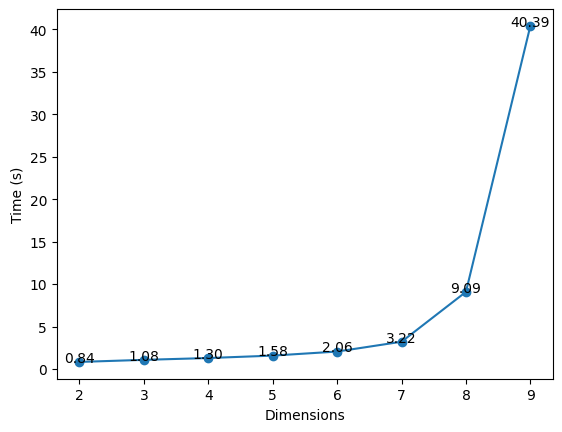

In [12]:
import util.perftest as perftest

with db.connect(DBNAME) as con:
    class ColumnBasedIntermediate(perftest.PerfTest):
        def name(self):
            return "column_based_intermediate"

        def setup_run(self, dimensions):
            constraints = generate_constraints_for_dimensions(dimensions - 1)
            generate_db_for_constraints(con, constraints)

        def run(self, dimensions):
            constraints = generate_constraints_for_dimensions(dimensions - 1)
            create_cad(con, constraints)
            result = con.execute("SELECT * FROM Result WHERE truth_value")

        def x_labels(self):
            return [3, 4, 5, 6, 7, 8, 9,]

    cad_perftest = perftest.measure_performance(ColumnBasedIntermediate())
    perftest.plot_df(cad_perftest, "Dimensions")

As expected, we have an exponential liftoff, which is inherent to CAD.